## Train/Test Split
Chronological 80/20 split — no shuffling to prevent data leakage.

In [155]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.style.use("dark_background")

In [156]:
prices = pd.read_csv('../data/prices.csv', index_col=0, parse_dates=True).squeeze()
returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True).squeeze()
target = pd.read_csv('../data/target.csv', index_col=0, parse_dates=True).squeeze()
features = pd.read_csv('../data/features.csv', index_col=0, parse_dates=True)

In [157]:
feature_names = features.columns.tolist()

X = features.replace([np.inf, -np.inf], np.nan)
y = target

data = X.join(y.rename('target')).dropna()
X = data[feature_names]
y = data['target']

n = int(len(data) * 0.8)
X_train, X_test = X.iloc[:n], X.iloc[n:]
y_train, y_test = y.iloc[:n], y.iloc[n:]
assert X_train.index.max() < X_test.index.min(), "Data leak!"
print(f"Train: {X_train.index.min()} → {X_train.index.max()}")
print(f"Test:  {X_test.index.min()} → {X_test.index.max()}")


Train: 2018-04-05 00:00:00 → 2022-11-02 00:00:00
Test:  2022-11-03 00:00:00 → 2023-12-28 00:00:00


In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [159]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(rmse_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print(r2_lr)

0.015036688048243435
-0.050050742974816265


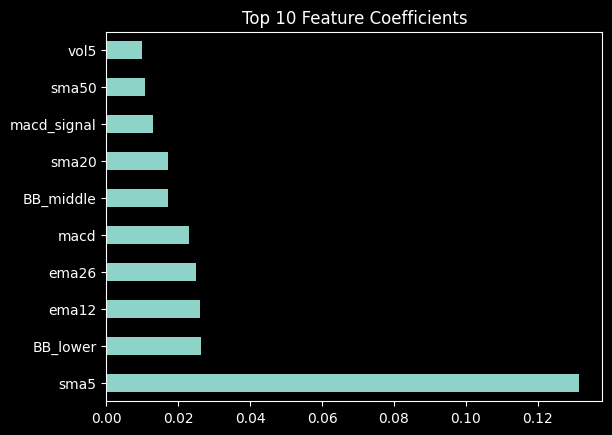

In [160]:
coeffs = pd.Series(lr.coef_, index=feature_names)
coeffs.abs().nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Coefficients')
plt.show()

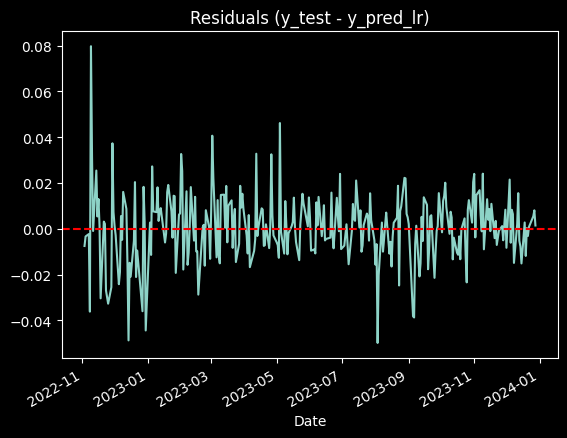

In [161]:
residuals = y_test - y_pred_lr
residuals.plot()
plt.title('Residuals (y_test - y_pred_lr)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

## Model: Random Forest
Ensemble of 200 decision trees to capture non-linear feature interactions.

In [162]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=20, n_jobs=-1, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"RF RMSE: {rmse_rf:.5f}")
print(f"RF R²: {r2_rf:.4f}")

RF RMSE: 0.01509
RF R²: -0.0571


In [163]:
from scipy.stats import spearmanr

dir_acc_rf = (np.sign(y_pred_rf) == np.sign(y_test)).mean()
ic_rf, pval_rf = spearmanr(y_pred_rf, y_test)

print(f"Directional Accuracy: {dir_acc_rf:.3f}")
print(f"IC (Spearman): {ic_rf:.4f}  p={pval_rf:.4f}")

Directional Accuracy: 0.474
IC (Spearman): 0.0151  p=0.7981


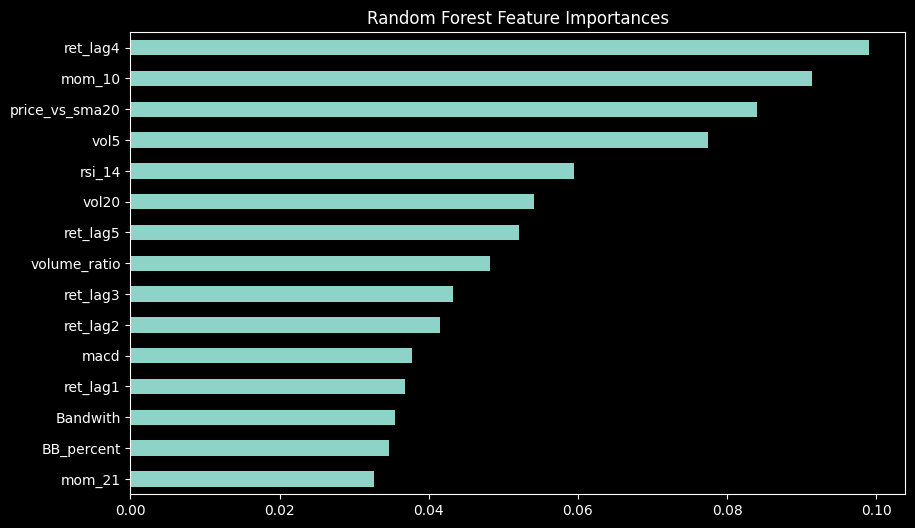

In [164]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().tail(15).plot(kind='barh', figsize=(10, 6))
plt.title('Random Forest Feature Importances')
plt.show()

In [165]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf],
    'Directional Accuracy': [
        (np.sign(y_pred_lr) == np.sign(y_test)).mean(),
        dir_acc_rf
    ],
    'IC': [
        spearmanr(y_pred_lr, y_test)[0],
        ic_rf
    ]
})

print(results.to_string(index=False))

            Model     RMSE        R2  Directional Accuracy        IC
Linear Regression 0.015037 -0.050051              0.470588 -0.007956
    Random Forest 0.015087 -0.057086              0.474048  0.015114


In [166]:
pd.Series(y_pred_lr, index=y_test.index).to_csv('../data/y_pred_lr.csv')
pd.Series(y_pred_rf, index=y_test.index).to_csv('../data/y_pred_rf.csv')
y_test.to_csv('../data/y_test.csv')
feat_imp.to_csv('../data/feat_imp.csv')

In [167]:
from scipy.stats import spearmanr
dir_acc_lr = (np.sign(y_pred_lr) == np.sign(y_test)).mean()
ic_lr, pval_lr = spearmanr(y_pred_lr, y_test)
print(f"LR Dir Acc: {dir_acc_lr:.3f}")
print(f"LR IC: {ic_lr:.4f}")

LR Dir Acc: 0.471
LR IC: -0.0080
